# Depth Anything V2

## Introducción

**Depth Anything V2** Depth Anything V2 es un modelo fundamental (foundation model) diseñado para la Estimación de Profundidad Monocular (MDE). Su objetivo es generar predicciones de profundidad mucho más detalladas y robustas que su predecesor (V1) y otros modelos actuales.

A diferencia de otros enfoques que utilizan técnicas complejas o modelos basados en difusión (que suelen ser lentos), Depth Anything V2 se centra en mejorar la calidad de los datos de entrenamiento para superar las limitaciones de los modelos discriminativos tradicionales.

**Propiedades Clave:**

* Robustez: Capaz de manejar escenas complejas, incluyendo superficies transparentes (vidrio) y reflectantes (espejos), donde otros modelos suelen fallar.
* Detalle Fino: Logra una precisión extrema en estructuras delgadas (como patas de sillas) y límites de objetos.
* Eficiencia: Es significativamente más rápido (más de 10 veces) que los modelos basados en Stable Diffusion, ofreciendo versiones que van desde los 25M hasta los 1.3B de parámetros.

El objetivo principal del modelo es generar un **mapa de profundidad**, donde cada píxel de la imagen representa una estimación relativa de la distancia entre la cámara y los objetos de la escena. Este tipo de modelos tiene aplicaciones en diversos campos, como:

- Robótica
- Vehículos autónomos
- Realidad aumentada
- Reconstrucción 3D
- Análisis de escenas
- Visión por computadora

Depth Anything V2 destaca por su capacidad de generalización, lo que significa que puede funcionar correctamente en distintos tipos de imágenes, incluso si no fueron vistas durante el entrenamiento.


## Arquitectura del modelo

La arquitectura de Depth Anything V2 se basa en un modelo discriminativo que utiliza codificadores visuales pre-entrenados de la familia ``DINOv2``.

La arquitectura de Depth Anything V2 no se basa en técnicas complejas o generativas (como la difusión), sino en un diseño discriminativo optimizado a través de una estrategia de datos muy rigurosa. Su objetivo es combinar la robustez en escenas complejas con una precisión extrema en los detalles.
### 1. Columna Vertebral (Backbone)

El encoder es responsable de extraer características de la imagen de entrada. Depth Anything V2 utiliza variantes de **Vision Transformers (ViT)** como backbone. Estas variantes permiten capturar información global de la imagen mediante mecanismos de atención.

El modelo utiliza codificadores visuales pre-entrenados de la familia DINOv2.
* **Variedad de escalas:** Se ofrecen cuatro versiones basadas en diferentes tamaños de ``DINOv2``: Small (25M de parámetros), Base, Large y Giant (1.3B de parámetros).
* **Naturaleza discriminativa:** A diferencia de modelos como Marigold (basados en Stable Diffusion), Depth Anything V2 es un modelo discriminativo, lo que lo hace más de 10 veces más rápido y eficiente en términos de memoria.

El modelo admite diferentes configuraciones de encoder:

| Encoder | Características | Parametros | Checkpoint |
|-------|-------|-------|-------|
| vits | versión pequeña del Vision Transformer | 24.8M | [Download](https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth?download=true) |
| vitb | versión base con mayor capacidad | 97.5M | [Download](https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth?download=true) |
| vitl | versión grande con más parámetros | 335.3M | [Download](https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth?download=true) |
| vitg | versión gigante para mayor precisión | 1.3B | Aun no ha salido

Cada encoder produce representaciones jerárquicas de la imagen en diferentes niveles de profundidad dentro de la red.

---

### 2. Pipeline de Entrenamiento (Estrategia Maestro-Estudiante)

* **Entrenamiento del Maestro (Teacher Model):** Se entrena el modelo más potente (DINOv2-Giant) exclusivamente con imágenes sintéticas de alta precisión. Los datos sintéticos proporcionan etiquetas perfectas para objetos transparentes, reflejos y estructuras muy finas que los sensores reales no pueden captar

* **Generación de Pseudo-etiquetas:** El modelo maestro procesa un conjunto masivo de 62 millones de imágenes reales sin etiquetar para asignarles "pseudo-etiquetas" de profundidad de alta calidad. Esto sirve de "puente" para que el modelo aprenda la distribución de imágenes del mundo real.

* **Entrenamiento de Estudiantes (Student Models):** Los modelos finales (incluyendo las versiones pequeñas) se entrenan únicamente con estas imágenes reales y sus pseudo-etiquetas precisas. Esto permite que un modelo pequeño (como el de 25M) herede la capacidad de detalle de un modelo gigante sin el costo computacional de este último
---

### 3. Funciones de Pérdida (Optimization)

Para garantizar la nitidez y la precisión, el modelo emplea dos funciones de pérdida principales:

* Pérdida Invariante a Escala y Desplazamiento ($\mathcal{L}_{ssi}$): Permite manejar la ambigüedad de la profundidad monocular.
* Pérdida de Coincidencia de Gradiente ($\mathcal{L}_{gm}$): Es fundamental para la nitidez de los bordes (sharpness). En la V2, se descubrió que aumentar el peso de esta pérdida al entrenar con datos sintéticos mejora drásticamente la definición de detalles finos, como patas de sillas o cables.
* Alineación de Características: En el entrenamiento con pseudo-etiquetas, se añade una pérdida para preservar la semántica informativa de los codificadores DINOv2 originales.

El resultado es un **mapa de profundidad denso**, donde cada píxel corresponde a una estimación de distancia relativa.

In [1]:
# %pip install gradio_imageslider gradio==4.29.0 matplotlib opencv-python torch torchvision

In [2]:
import cv2
import torch
import matplotlib.pyplot as plt
import sys
import os
from functions.graphic_comparation import graphic_comparation
sys.path.append(os.path.abspath("."))

In [3]:
import cv2
import torch

from depth_anything_v2.dpt import DepthAnythingV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

xFormers not available
xFormers not available


## Flujo general del modelo

El funcionamiento del modelo puede resumirse en las siguientes etapas:

1. **Entrada de imagen**
   - Una imagen RGB es proporcionada como entrada.

2. **Extracción de características**
   - El encoder basado en Vision Transformers procesa la imagen y extrae representaciones de alto nivel.

3. **Fusión multiescala**
   - Se combinan diferentes niveles de características.

4. **Reconstrucción del mapa de profundidad**
   - El decoder genera un mapa de profundidad con la misma resolución aproximada de la imagen de entrada.

In [4]:
def get_infer_image(encoder: str, image_in):
    model = DepthAnythingV2(**model_configs[encoder])
    model.load_state_dict(torch.load(f'checkpoints/depth_anything_v2_{encoder}.pth', map_location='cpu'))
    model = model.to(DEVICE).eval()

    image_out = f"D:/Ciencias/Modelos monoculares/Depth Anything V2/assets/results/{encoder}_{image_in.split("/")[-1]}"

    raw_img = cv2.imread(image_in)
    depth = model.infer_image(raw_img)
    cv2.imwrite(image_out, depth)
    graphic_comparation(raw_img, depth)

## Ejemplos de uso con imagenes en ambientes de basura

El modelo produce un **mapa de profundidad monocular**, que es una matriz donde:

- valores bajos representan objetos cercanos
- valores altos representan objetos más lejanos

Este mapa puede visualizarse en escala de grises o utilizando mapas de color (colormaps) para facilitar su interpretación.


C:\Users\Animetx\AppData\Local\Temp\ipykernel_4584\2808963496.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'checkpoints/depth_anythi

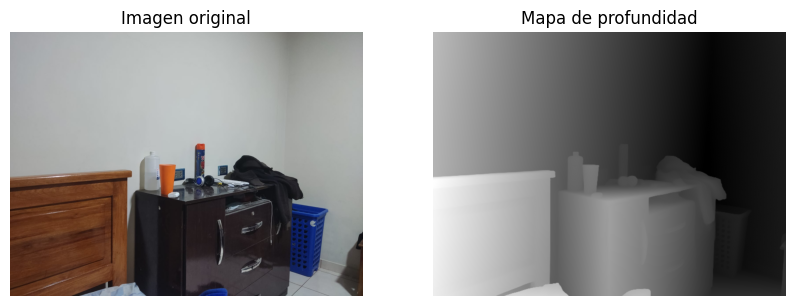

In [5]:
# encoder = 'vitl' # or 'vits', 'vitb', 'vitg'
image_in = 'D:/Ciencias/Modelos monoculares/Depth Anything V2/assets/examples/example01.jpeg'
get_infer_image('vitl', image_in)

C:\Users\Animetx\AppData\Local\Temp\ipykernel_4584\2808963496.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'checkpoints/depth_anythi

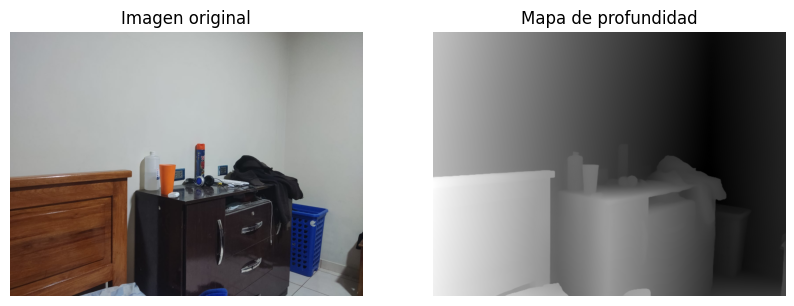

In [6]:
# encoder = 'vitl' # or 'vits', 'vitb', 'vitg'
get_infer_image('vits', image_in)

C:\Users\Animetx\AppData\Local\Temp\ipykernel_4584\2808963496.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'checkpoints/depth_anythi

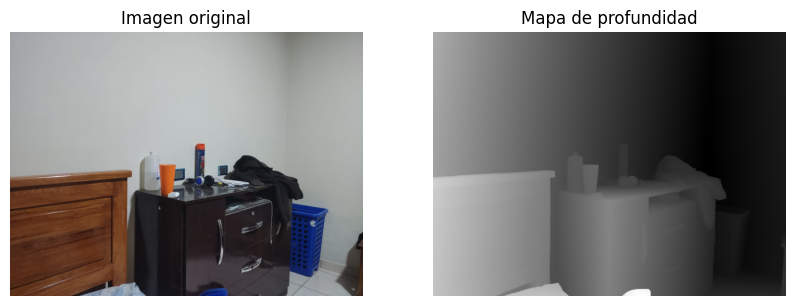

In [7]:
# encoder = 'vitl' # or 'vits', 'vitb', 'vitg'
get_infer_image('vitb', image_in)

## Ventajas de Depth Anything V2

Entre las principales ventajas del modelo se encuentran:

- Alta capacidad de generalización a diferentes tipos de escenas.
- Mejora en la precisión respecto a versiones anteriores.
- Uso eficiente de Vision Transformers para capturar contexto global.
- Capacidad de producir mapas de profundidad densos y detallados.

Estas características lo convierten en una herramienta importante dentro del campo de la **visión por computadora y la estimación de profundidad monocular**.

## Referencias

- Depth Anything V2. Disponible en: https://github.com/DepthAnything/Depth-Anything-V2

## Credits

This project uses components from the Depth Anything V2 repository.

Original repository:
https://github.com/DepthAnything/Depth-Anything-V2

Licensed under the Apache License 2.0.